In [1]:
import ray_tracing_cuda_float_torch as rt
import torch

In [2]:
def gradinc( grads, x, step, niter ):

    iters = [ x ]

    for k in range( niter ):

        for g in grads:

            x = x - step * g( x )

        iters.append( x )

    return iters

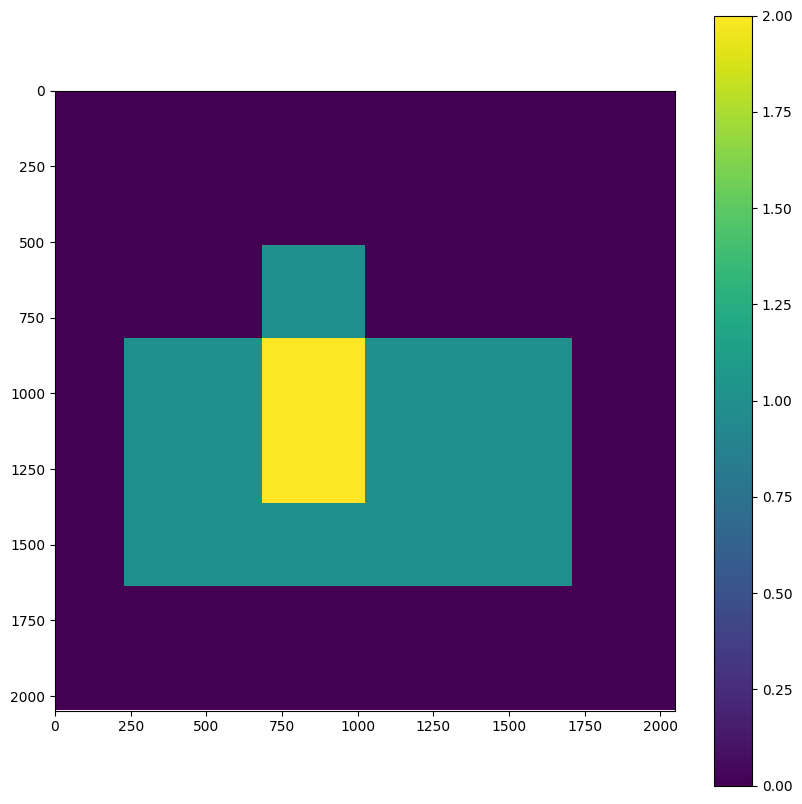

In [3]:
import matplotlib.pyplot as pp

n = 2048
img = torch.zeros( ( n, n ), device = 'cuda' )
img[ int( n / 4 ) : int( n / 1.5 ), int( n / 3 ) : int( n / 2 ) ] += 1.0
img[ int( n / 2.5 ) : int( n / 1.25 ), int( n / 9 ) : int( n / 1.2 ) ] += 1.0

pp.figure( figsize = ( 10, 10 ) )
pp.imshow( img.cpu(), interpolation = 'nearest' )
pp.colorbar()
pp.show()

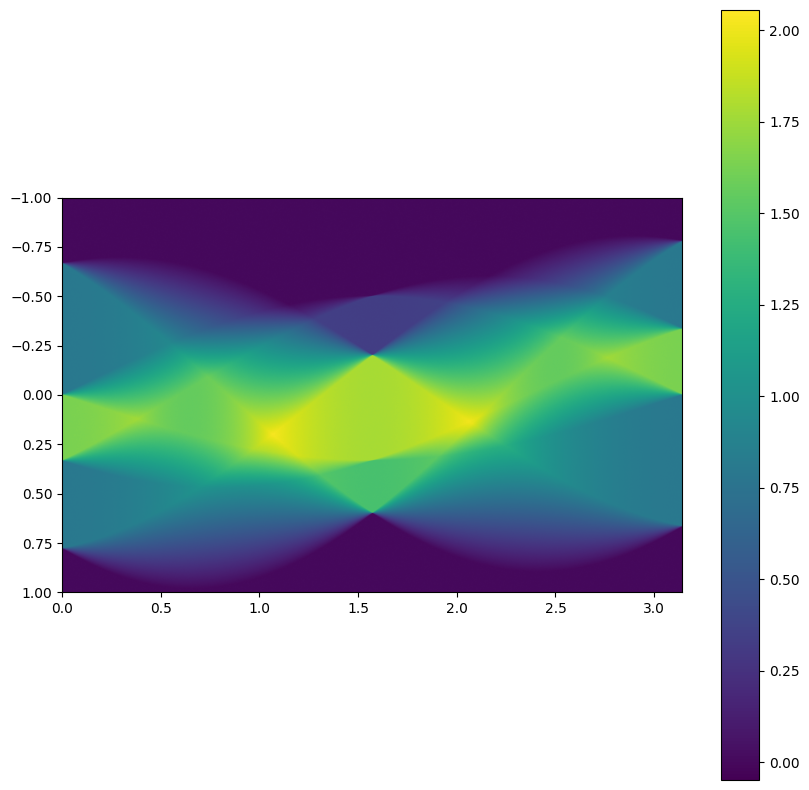

In [4]:
( radon, radon_transpose ) = rt.make_radon_transp(
    ( n, n ),
    sino_top_left = ( 0.0, 1.0 ),
    sino_bottom_right = ( torch.pi, -1.0 ),
    img_shape = ( n, n )    
)

b = radon( img )
b = b + 1e-2 * torch.randn_like( b, device = 'cuda' )

pp.figure( figsize = ( 10, 10 ) )
pp.imshow( b.cpu(), extent = ( 0.0, torch.pi, 1.0, -1.0 ) )
pp.colorbar()
pp.show()

In [5]:
def cria_grads( c, sino, theta_extent = ( 0, torch.pi ) ):

    ini_col = 0

    delta_theta = ( theta_extent[ 1 ] - theta_extent[ 0 ] ) / ( sino.shape[ 1 ] - 1 )

    grads = []

    for k in range( c ):
        n_cols = int( sino.shape[ 1 ] / c ) + int( k < ( sino.shape[ 1 ] % c ) )

        end_col = ini_col + n_cols

        b_k = sino[ :, ini_col : end_col ]

        theta_i = theta_extent[ 0 ] + delta_theta * ini_col
        theta_f = theta_extent[ 0 ] + delta_theta * ( end_col - 1 )

        radon, radon_transpose = rt.make_radon_transp(
            ( sino.shape[ 0 ], n_cols ),
            sino_top_left = ( theta_i, 1.0 ),
            sino_bottom_right = ( theta_f, -1.0 ),
            img_shape = ( sino.shape[ 0 ], sino.shape[ 0 ] )
        )

        def make_grad( r, rt, b ):
            def grad( x ):

                return rt( r( x ) - b )
            return grad
        
        grads.append( make_grad( radon, radon_transpose, b_k ) )

        ini_col = end_col

    return grads

In [6]:
# Altere aqui o número de subconjuntos:
c = 20
grads = cria_grads( c, b )

iters = gradinc( grads, torch.zeros( ( n, n ), device = 'cuda' ), 2.5e-1 * c, 100 )

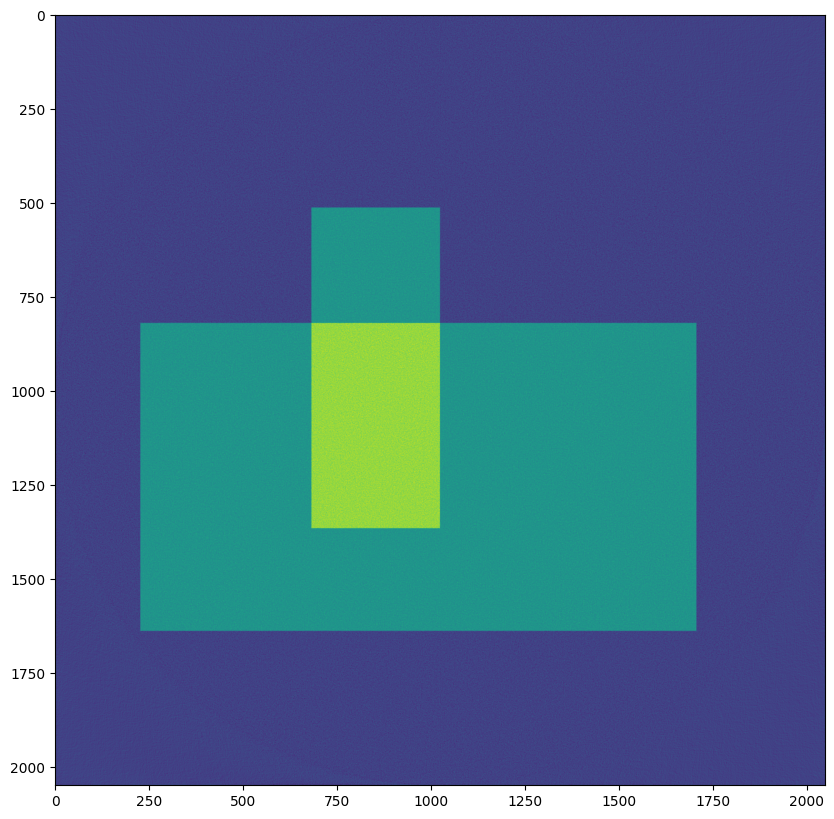

In [7]:
pp.figure( figsize = ( 10, 10 ) )
pp.imshow( iters[ -1 ].cpu() )
pp.show()